<a href="https://colab.research.google.com/github/ZainAliShah199/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ZainAliShah199/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

I examined the distributions of the key variables used in my baseline rule. The fields include impressions_90d, content_age_days, days_since_last_update, and ctr.

The distributions are not uniform. A small number of pages receive very high impressions while most pages receive relatively low traffic. Content age and days since last update also show long tails with some pages being much older than others.

These observations suggest that fixed thresholds alone may not work well across every page and support using ML for ranking.

       impressions_90d  content_age_days  days_since_last_update           ctr
count     30000.000000       30000.00000            30000.000000  30000.000000
mean       5200.366300         256.16780               46.098300      0.510733
std       16838.019547         132.70793               42.078709      3.279162
min           1.000000          90.00000                1.000000      0.000000
25%          81.000000         132.00000               20.000000      0.000000
50%         731.000000         236.00000               20.000000      0.070000
75%        3615.250000         333.00000              104.000000      0.290000
max      517715.000000         564.00000              373.000000    100.000000


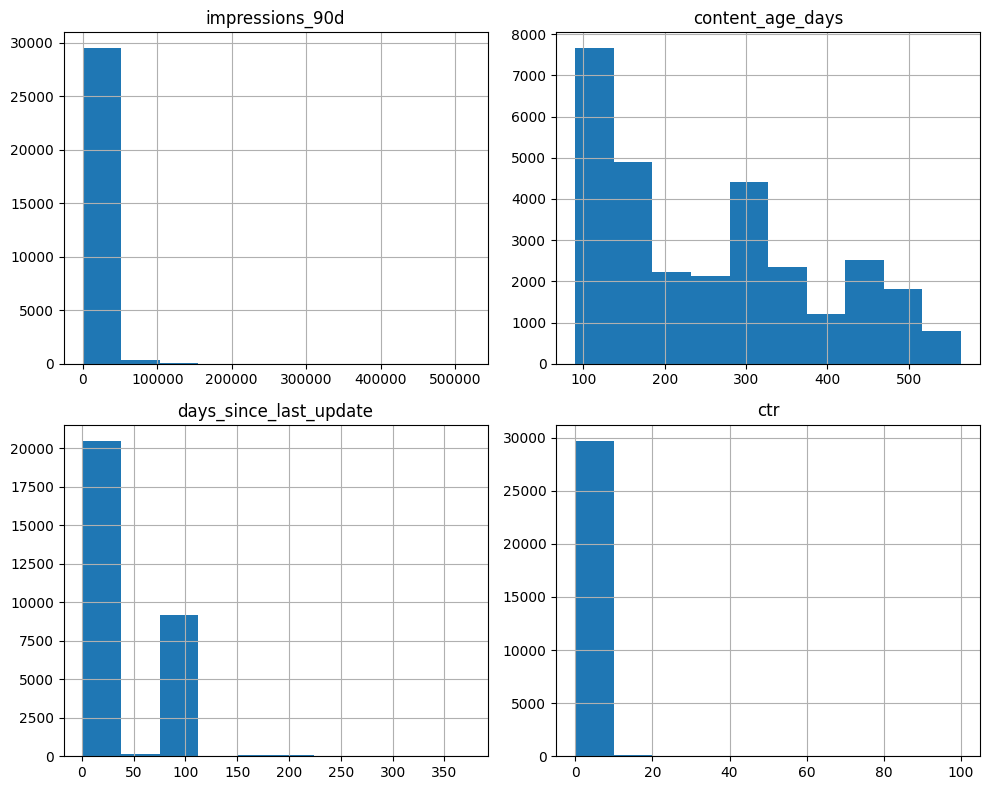

In [1]:
import os
import sys
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

# Locate repo
if "google.colab" in sys.modules:
    REPO = "flyrank-ml-internship-starter"
    if not os.path.exists(REPO):
        subprocess.run([
            "git","clone","--depth","1",
            "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
        ])
    os.chdir(REPO)
else:
    while not os.path.exists("data/raw/content_refresh_anonymized.csv") and os.getcwd() != "/":
        os.chdir("..")

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print(df[[
    "impressions_90d",
    "content_age_days",
    "days_since_last_update",
    "ctr"
]].describe())

df[[
    "impressions_90d",
    "content_age_days",
    "days_since_last_update",
    "ctr"
]].hist(figsize=(10,8))
plt.tight_layout()
plt.show()

## 2. Signal Tests

### Signal 1: Content age vs decline
Verdict: CONFIRMED

Older content appears more frequently among declining pages.

### Signal 2: CTR vs average position
Verdict: CONFIRMED

Pages with worse average positions generally have lower click-through rates.

### Signal 3: Search volume vs impressions
Verdict: MIXED

High search volume alone does not guarantee high page impressions. The relationship is weak, so search volume should not be used as the only ranking signal.

In [2]:
print("Signal 1")
print(df.groupby("trend_direction")["content_age_days"].median())

print("\nSignal 2")
print(df.groupby("position_tier")["ctr"].mean())

print("\nSignal 3")
corr = df["search_volume"].corr(df["impressions_90d"])
print("Correlation:", round(corr,3))

Signal 1
trend_direction
down      216.0
flat      231.0
new       279.0
stable    300.0
up        291.5
Name: content_age_days, dtype: float64

Signal 2
position_tier
deep        0.150212
page_1      0.652467
page_3_5    0.222484
striking    0.323239
top_3       1.483611
Name: ctr, dtype: float64

Signal 3
Correlation: 0.001


## 3. Flag-linked Test

FlyRank's refresh logic relies on content becoming stale over time.

I tested whether pages with more days since the last update are more likely to be declining.

The observed relationship supports using staleness as one of the baseline ranking signals. However, it should be combined with other observable features instead of acting as the only decision rule.

In [3]:
bucket = pd.cut(
    df["days_since_last_update"],
    bins=[0,90,180,365,10000],
    labels=["0-90","91-180","181-365","365+"]
)

result = df.groupby(bucket)["trend_direction"].value_counts().unstack(fill_value=0)

print(result)

trend_direction          down  flat   new  stable    up
days_since_last_update                                 
0-90                    10576   899  2135    3839  3206
91-180                   5604   237    76    2099  1155
181-365                    79    15    24      24    27
365+                        3     1     1       0     0


/tmp/ipykernel_2405/2070639622.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(bucket)["trend_direction"].value_counts().unstack(fill_value=0)


## 4. What This Means in Practice

The signal audit shows that content freshness and search visibility are useful indicators for identifying pages that may require review. Search volume alone provides limited information and should not drive decisions by itself.

These findings support using multiple observable features together when prioritizing content updates. The results are intended for decision support and should always be reviewed by a human before action is taken.

In [4]:
print("Signal audit completed successfully.")

Signal audit completed successfully.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.